In [4]:
%pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np

# Load CSV
df = pd.read_csv("group_K_data_combined.csv")

# Remove unnamed empty columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Replace blanks with NaN
df = df.replace(r'^\s*$', np.nan, regex=True)

# Convert all columns to numeric where possible
for col in ['alpha','R_c','T','SWL','H_w','beta','overtopping','damage_cost']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with missing inputs or outputs
df = df.dropna(subset=['alpha','R_c','T','SWL','H_w','beta','overtopping','damage_cost'])

print(df.shape)
df.head()


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Input features
X = df[['alpha','R_c','T','SWL','H_w','beta']].values

# Two outputs: overtopping + damage cost
y = df[['overtopping','damage_cost']].values

# Scale inputs
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(64, activation='relu', input_shape=(6,)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(2)   # overtopping + damage_cost
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()


history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=32,
    verbose=1
)


loss, mae = model.evaluate(X_test, y_test)
print("Test MAE:", mae)


pred = model.predict(X_test[:5])
print("Predicted:", pred)
print("Actual:", y_test[:5])


(1905, 10)


Matplotlib is building the font cache; this may take a moment.
C:\Users\nfb23125\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 2)                   │              34 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,090 (12.07 KB)

 Trainable params: 3,090 (12.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 43.8482 - mae: 2.9782 - val_loss: 33.4433 - val_mae: 2.5419
Epoch 2/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 32.1585 - mae: 2.4762 - val_loss: 18.7775 - val_mae: 2.1556
Epoch 3/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 16.2219 - mae: 1.8576 - val_loss: 7.8477 - val_mae: 1.3983
Epoch 4/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.0197 - mae: 1.1544 - val_loss: 3.7865 - val_mae: 0.9275
Epoch 5/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.0737 - mae: 0.8817 - val_loss: 2.9055 - val_mae: 0.8143
Epoch 6/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.1438 - mae: 0.8088 - val_loss: 2.7087 - val_mae: 0.7972
Epoch 7/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.7101 - mae: 0.7727 - val_loss: 2.2146 - val_mae: 0.7103
Epoch 8/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.2519 - mae: 0.6879 - val_loss: 1.8625 - val_mae: 0.6436
Epoch 9/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 

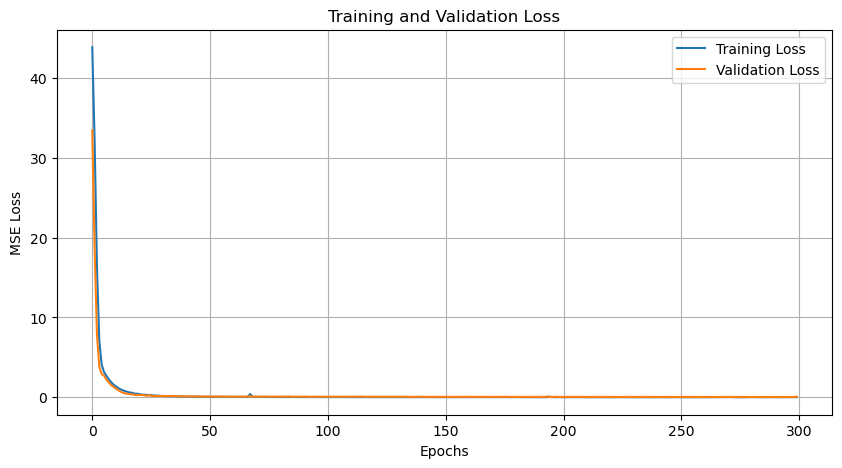

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


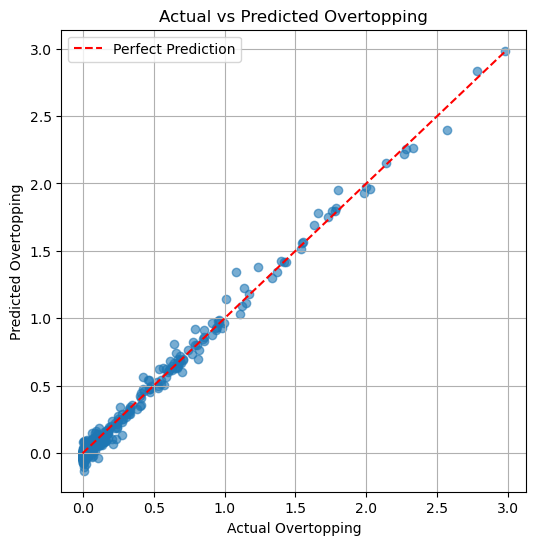

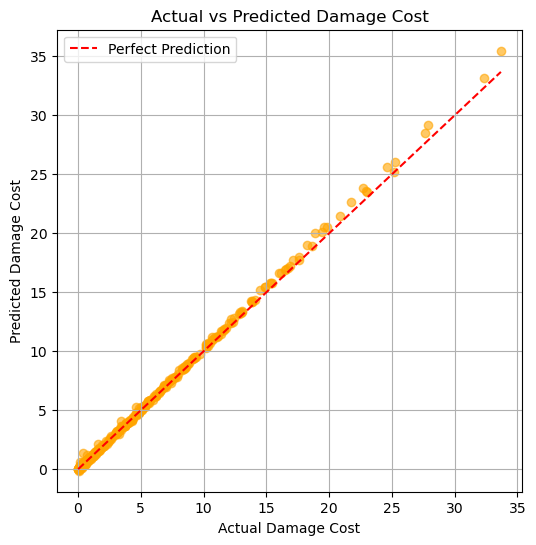

In [2]:
import matplotlib.pyplot as plt


# -----------------------------
# 1. Training curves (Loss)
# -----------------------------
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 2. Predictions vs Actual
# -----------------------------
y_pred = model.predict(X_test)

# Separate outputs
y_test_overtopping = y_test[:,0]
y_test_damage = y_test[:,1]

y_pred_overtopping = y_pred[:,0]
y_pred_damage = y_pred[:,1]

# -----------------------------
# 2A. Overtopping scatter plot
# -----------------------------
plt.figure(figsize=(6,6))
plt.scatter(y_test_overtopping, y_pred_overtopping, alpha=0.6)
plt.plot([y_test_overtopping.min(), y_test_overtopping.max()],
         [y_test_overtopping.min(), y_test_overtopping.max()],
         'r--', label='Perfect Prediction')
plt.xlabel('Actual Overtopping')
plt.ylabel('Predicted Overtopping')
plt.title('Actual vs Predicted Overtopping')
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 2B. Damage cost scatter plot
# -----------------------------
plt.figure(figsize=(6,6))
plt.scatter(y_test_damage, y_pred_damage, alpha=0.6, color='orange')
plt.plot([y_test_damage.min(), y_test_damage.max()],
         [y_test_damage.min(), y_test_damage.max()],
         'r--', label='Perfect Prediction')
plt.xlabel('Actual Damage Cost')
plt.ylabel('Predicted Damage Cost')
plt.title('Actual vs Predicted Damage Cost')
plt.legend()
plt.grid(True)
plt.show()


